In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, GreedyAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import COAPAgent
from ant.centralised import P4
from ant.decentralised.utility import create_grid_graph

In [2]:
NUM_SEEDS = 10
MARKET_SIZE = 8
SIMULATION_DURATION = 50
WINDOW_START = 0
WINDOW_END = min(SIMULATION_DURATION, 50)

# Community size
KS = [
    1,
    2,
    3,
    # 4,
    # 5,
    # 6,
    # 7
]

BENCHMARKS = ["PROP"]
TARGET_AGENTS = ["COAP"]

GRAPH_TYPES = ["Fully Connected", "Random", "Grid", "Small-World"]

MARKET_SCORE_INSTEAD_OF_UTILITY = 0

In [3]:
def create_graphs(n, seed):
    graphs = {
        "Fully Connected": nx.complete_graph(n),
        # "Random": nx.gnp_random_graph(n, 0.1, seed=seed),
        "Random": nx.erdos_renyi_graph(n, 0.1),
        "Grid": create_grid_graph(n),
        "Small-World": nx.watts_strogatz_graph(n, int(n / 2), 0.05, seed=seed),
    }
    for g_type in GRAPH_TYPES:
        if not nx.is_connected(graphs[g_type]):
            return create_graphs(n, seed + NUM_SEEDS)
    return graphs

In [4]:
results_store = {}
crash_rates_store = {}

for graph_type in GRAPH_TYPES:
    results_store[graph_type] = {}
    crash_rates_store[graph_type] = {}

    for agent_strategy in TARGET_AGENTS + BENCHMARKS:
        if agent_strategy == "COAP":
            keys = KS
        else:
            keys = [None]

        results_store[graph_type][agent_strategy] = {k_val: [] for k_val in keys}
        crash_rates_store[graph_type][agent_strategy] = {k_val: [] for k_val in keys}

In [5]:
print(f"Starting simulation loop for {NUM_SEEDS} seeds...")

for seed_idx in range(NUM_SEEDS):
    # Use the same seed index for both the Agent randomness AND the Graph generation
    current_seed = seed_idx

    # 1. Generate NEW Topologies for this specific seed
    graphs = create_graphs(MARKET_SIZE, seed=current_seed)

    for graph_type, graph_obj in graphs.items():
        # 2. Run COAP Agents
        for k in KS:
            _market = Market(
                MARKET_SIZE,
                graph=graph_obj,
                seed=current_seed,  # Seed for agents/resources
                agent_type=COAPAgent,
                resource_volatility=0.01,
                k=k,
                report_crashes=True,
            )

            # Compute Optimal Allocations
            optimal_allocations, utility_vector = P4(_market)
            _market.set_market_equilibrium(optimal_allocations, utility_vector)

            # SimulaMARKET_SCORE_INSTEAD_OF_UTILITY
            if MARKET_SCORE_INSTEAD_OF_UTILITY == 1:
                sim_result = _market.simulate(
                    SIMULATION_DURATION,
                    use_average_in_market_loss=False,
                    return_proportional_utility_instead_of_market_loss=True,
                )

            else:
                sim_result = _market.simulate(
                    SIMULATION_DURATION,
                    use_average_in_market_loss=True,
                    return_proportional_utility_instead_of_market_loss=False,
                )

            window_data = sim_result[WINDOW_START:WINDOW_END]

            # Calculate health/crash rate
            crash_count = sum(
                [1 if agent.has_crashed else 0 for agent in _market.agents]
            )
            crash_rate = 1.0 - (crash_count / len(_market.agents))

            results_store[graph_type]["COAP"][k].append(window_data)
            crash_rates_store[graph_type]["COAP"][k].append(crash_rate)

        # 3. Run Benchmark Agents (e.g., Proportional)
        for b_agent in BENCHMARKS:
            agent_type = ProportionalAgent if b_agent == "PROP" else None

            if agent_type:
                _market = Market(
                    MARKET_SIZE,
                    graph=graph_obj,
                    seed=current_seed,
                    agent_type=agent_type,
                )

                optimal_allocations, utility_vector = P4(_market)
                _market.set_market_equilibrium(optimal_allocations, utility_vector)

                if MARKET_SCORE_INSTEAD_OF_UTILITY == 1:
                    sim_result = _market.simulate(
                        SIMULATION_DURATION,
                        use_average_in_market_loss=False,
                        return_proportional_utility_instead_of_market_loss=True,
                    )

                else:
                    sim_result = _market.simulate(
                        SIMULATION_DURATION,
                        use_average_in_market_loss=True,
                        return_proportional_utility_instead_of_market_loss=False,
                    )
                window_data = sim_result[WINDOW_START:WINDOW_END]
                results_store[graph_type][b_agent][None].append(window_data)

    print(f"Completed seed {seed_idx + 1}/{NUM_SEEDS}")

Starting simulation loop for 10 seeds...
Completed seed 1/10
Completed seed 2/10
Completed seed 3/10
Completed seed 4/10
Completed seed 5/10
Completed seed 6/10
Completed seed 7/10
Completed seed 8/10
Completed seed 9/10
Completed seed 10/10


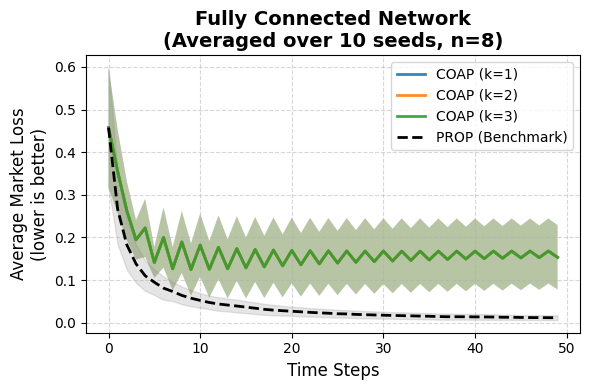


--- Summary Stats for Fully Connected ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.1536          0.0754          100.00%
COAP            2     0.1536          0.0754          100.00%
COAP            3     0.1536          0.0754          100.00%
PROP            -     0.0119          0.0056          100.00%


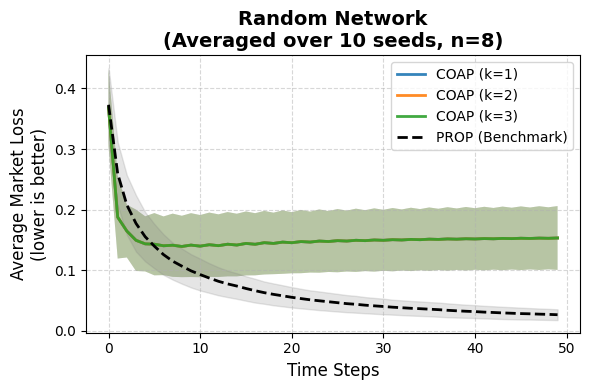


--- Summary Stats for Random ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.1532          0.0527          100.00%
COAP            2     0.1532          0.0527          100.00%
COAP            3     0.1532          0.0527          100.00%
PROP            -     0.0266          0.0089          100.00%


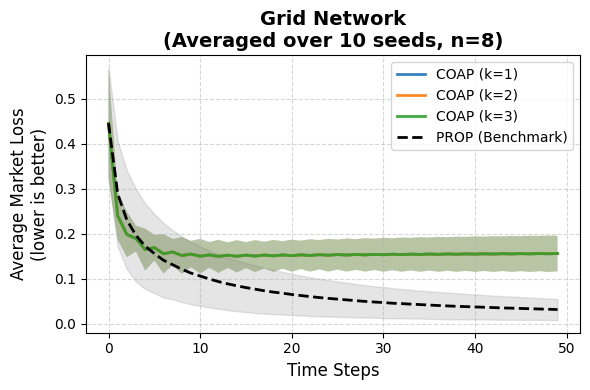


--- Summary Stats for Grid ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.1558          0.0395          100.00%
COAP            2     0.1558          0.0395          100.00%
COAP            3     0.1558          0.0395          100.00%
PROP            -     0.0313          0.0235          100.00%


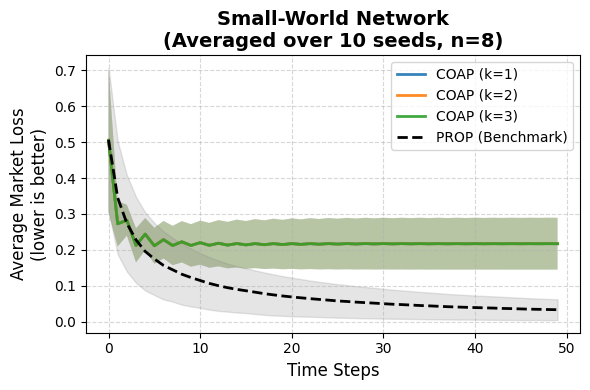


--- Summary Stats for Small-World ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.2171          0.0721          100.00%
COAP            2     0.2171          0.0721          100.00%
COAP            3     0.2171          0.0721          100.00%
PROP            -     0.0333          0.0290          100.00%


In [6]:
time_steps = np.arange(WINDOW_START, WINDOW_END)

for graph_type in results_store.keys():
    plt.figure(figsize=(6, 4))
    axis = plt.gca()

    # Plot COAP agents
    for k in KS:
        data_list = results_store[graph_type]["COAP"][k]

        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)

            label = f"COAP (k={k})"

            plt.plot(time_steps, mean_loss, label=label, alpha=0.9, linewidth=2)
            plt.fill_between(
                time_steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2
            )

    # Plot Benchmarks
    for bench in BENCHMARKS:
        data_list = results_store[graph_type][bench][None]
        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)

            label = f"{bench} (Benchmark)"

            plt.plot(
                time_steps,
                mean_loss,
                label=label,
                linestyle="--",
                color="black",
                linewidth=2,
            )
            plt.fill_between(
                time_steps,
                mean_loss - std_loss,
                mean_loss + std_loss,
                alpha=0.2,
                color="gray",
            )

    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Average Market Loss\n(lower is better)", fontsize=12)
    plt.title(
        f"{graph_type} Network\n(Averaged over {NUM_SEEDS} seeds, n={MARKET_SIZE})",
        fontsize=14,
        fontweight="bold",
    )
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Print Summary Table for this graph type
    print(f"\n--- Summary Stats for {graph_type} ---")
    print(
        f"{'Strategy':<15} {'K':<5} {'Final Mean Loss':<15} {'Final Std Dev':<15} {'Avg Health'}"
    )
    print("-" * 60)

    # COAP Agents
    for k in KS:
        data = results_store[graph_type]["COAP"][k]
        if data:
            # Take the last element of every seed run
            final_values = [d[-1] if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))
            final_std = float(np.std(final_values))
            avg_health = float(np.mean(crash_rates_store[graph_type]["COAP"][k]))
            print(
                f"{'COAP':<15} {str(k):<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}"
            )

    # Benchmark Agents
    for bench in BENCHMARKS:
        data = results_store[graph_type][bench][None]
        if data:
            # Data check
            final_values = [float(d[-1]) if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))

            final_std = float(np.std(final_values))

            # Calculate health. 100% unless COAP crashed
            rates = crash_rates_store[graph_type][bench][None]
            avg_health = float(np.mean(rates)) if rates else 1.0

            print(
                f"{bench:<15} {'-':<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}"
            )
        else:
            print(f"{bench:<15} {'-':<5} {'N/A':<15} {'N/A':<15} {'N/A':<10}")